In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from narwhals.selectors import categorical
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import shap
import optuna
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [159]:
application_train = pd.read_csv("train_features.csv")
application_test = pd.read_csv("test_features.csv")

In [160]:
application_train.shape

(307511, 177)

In [161]:
application_test.shape

(48744, 176)

In [163]:
application_train.head()

,Unnamed: 0,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,max_amt_credit,mean_percentage_recieved,mean_amt_down_payment,max_amt__down_payment,prev_application_count,prev_approved,prev_refused,prev_approval_rate,prev_expenses_on_other_ratio_mean,prev_expenses_on_other_ratio_max
0,0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,...,179055.0,0.999994,0.00,0.0,1.0,1.0,0.0,1.000000,0.000000,0.000000
1,1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,...,1035882.0,1.057658,3442.50,6885.0,3.0,3.0,0.0,1.000000,0.050671,0.131175
2,2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,...,20106.0,0.827987,4860.00,4860.0,1.0,1.0,0.0,1.000000,-0.207699,-0.207699
3,3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,...,906615.0,1.012677,34840.17,66987.0,9.0,5.0,1.0,0.555556,-0.010763,0.240582
4,4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,...,284400.0,1.046339,3390.75,3676.5,6.0,6.0,0.0,1.000000,0.030350,0.208861


In [164]:
application_test.head()

,Unnamed: 0,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,max_amt_credit,mean_percentage_recieved,mean_amt_down_payment,max_amt__down_payment,prev_application_count,prev_approved,prev_refused,prev_approval_rate,prev_expenses_on_other_ratio_mean,prev_expenses_on_other_ratio_max
0,0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,23787.0,0.957744,2520.0,2520.0,1.0,1.0,0.0,1.00,-0.044079,-0.044079
1,1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,...,40153.5,0.899929,4464.0,4464.0,2.0,1.0,0.0,0.50,-0.111173,-0.111173
2,2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,...,512370.0,1.052340,3375.0,6750.0,4.0,3.0,0.0,0.75,0.043497,0.121728
3,3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,...,225000.0,0.967465,3750.0,11250.0,5.0,3.0,0.0,0.60,-0.036037,0.000000
4,4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,...,508495.5,1.131349,8095.5,8095.5,2.0,1.0,0.0,0.50,0.115997,0.125808


In [165]:
application_train.drop(columns=["Unnamed: 0"], inplace=True)
application_test.drop(columns=["Unnamed: 0"], inplace=True)

In [166]:
y = application_train["TARGET"]
X = application_train.drop("TARGET", axis=1)

In [167]:
numerical_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

In [168]:
print(len(numerical_cols))
print(len(categorical_cols))

159
16


In [169]:
# Alle Spalten in X
all_cols = X.columns.tolist()

# Differenz berechnen: Alle Spalten minus (numerisch + kategorisch)
missing_cols = [col for col in all_cols if col not in numerical_cols and col not in categorical_cols]

print(f"Spalten ohne Zuordnung: {missing_cols}")

Spalten ohne Zuordnung: []


In [170]:
for col in categorical_cols:
    X[col] = X[col].astype('category')
    application_test[col] = application_test[col].astype('category')

In [171]:
import re
[col for col in X.columns if re.search(r'[^A-Za-z0-9_]', col)]

[]

In [172]:
X.dtypes[X.dtypes == 'object']

Series([], dtype: object)

In [206]:
print(X["CODE_GENDER"].dtype)

category


In [174]:
#Probieren wir es zuerst mit einem LightGBM

In [175]:
GBM = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31
)
GBM.fit(X, y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [176]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(GBM, X, y, cv=cv, n_jobs=-1, scoring="roc_auc")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082781 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21867
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 171
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.247053 seconds.
You can set `force_col_wise=true` to remove th

In [177]:
scores.mean()
#Output: 0.7758985820151467

np.float64(0.7750605161662427)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

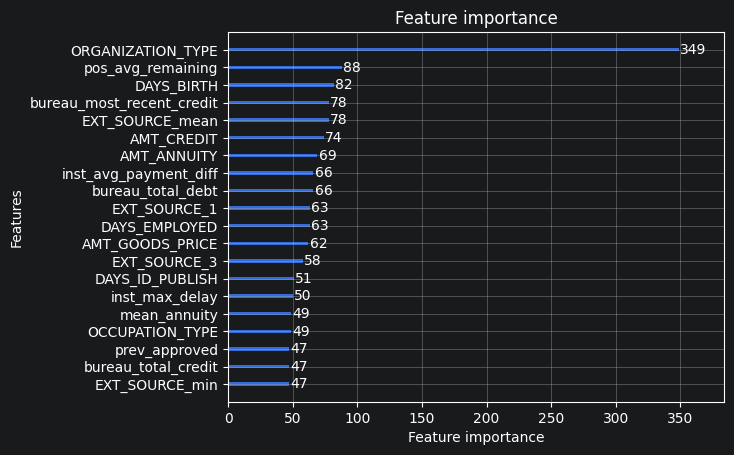

In [178]:
lgb.plot_importance(GBM, max_num_features=20)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


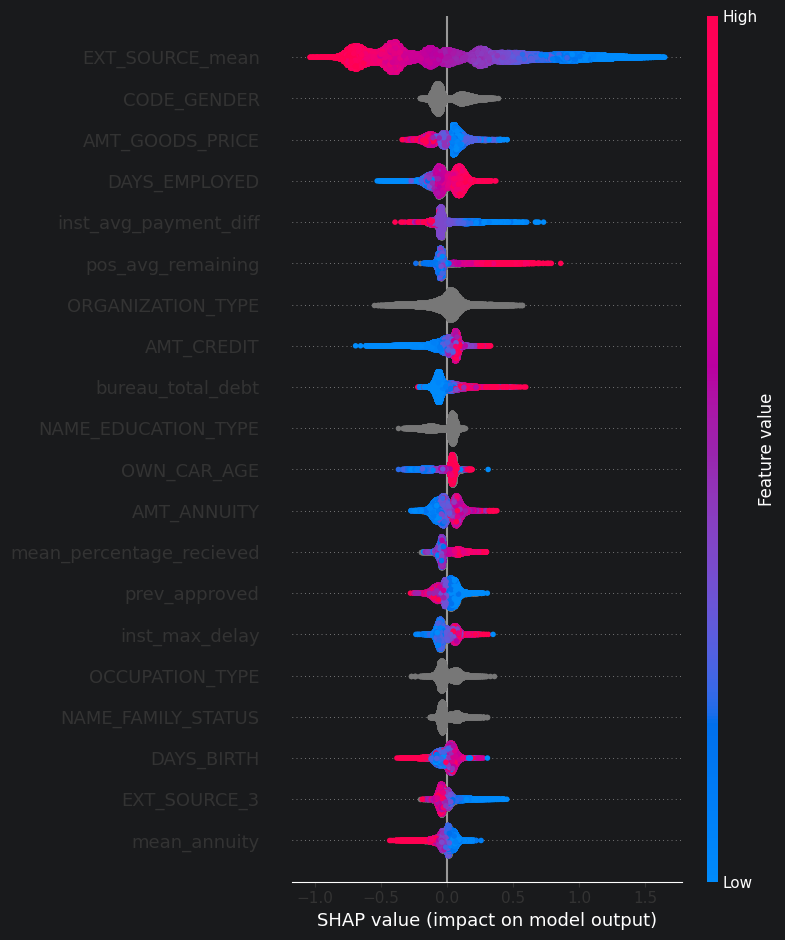

In [179]:
explainer = shap.TreeExplainer(GBM)
shap_values = explainer.shap_values(X)

# Global: welche Features sind insgesamt wichtig
shap.summary_plot(shap_values, X, max_display=20)

In [180]:
def submission(model):
    X_test = application_test.copy()
    predictions = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeit für Klasse 1

    # Submission erstellen
    submission = pd.DataFrame({
        "SK_ID_CURR": application_test["SK_ID_CURR"],
        "TARGET": predictions
    })
    return submission

In [181]:
#Besseres Boosting Model:

In [182]:
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators': 2000,
        'random_state': 42,
        'verbose': -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    best_iterations = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
            categorical_feature=categorical_cols
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))
        best_iterations.append(model.best_iteration_)

    trial.set_user_attr("best_n_estimators", int(np.mean(best_iterations)))
    return np.mean(auc_scores)

In [183]:
study = optuna.create_study(
    direction='maximize',
    storage="sqlite:///lgbm_study.db",
    study_name="lgbm_v4",
    load_if_exists=True
)

study.optimize(objective, n_trials=10)

best_n_estimators = study.best_trial.user_attrs["best_n_estimators"]
print(f"Optimale Anzahl Bäume: {best_n_estimators}")
#[I 2026-05-08 00:12:11,608] Trial 99 finished with value: 0.7749346691050608 and parameters: {'num_leaves': 20, 'learning_rate': 0.20255499763057377, 'min_child_samples': 90, 'subsample': 0.7372678581712692, 'colsample_bytree': 0.8425499076626509, 'reg_alpha': 1.665153387102547, 'reg_lambda': 0.002769154063466205}. Best is trial 87 with value: 0.780503076333318.
#Optimale Anzahl Bäume: 555 study_name: lgbm_v2

[I 2026-05-08 11:43:06,729] Using an existing study with name 'lgbm_v4' instead of creating a new one.
[I 2026-05-08 11:43:17,682] Trial 51 finished with value: 0.7733141355382299 and parameters: {'num_leaves': 40, 'learning_rate': 0.23978827640552774, 'min_child_samples': 53, 'subsample': 0.7158713030517003, 'colsample_bytree': 0.5870330166573225, 'reg_alpha': 4.212049764339549, 'reg_lambda': 3.819333531357288e-07}. Best is trial 28 with value: 0.778563323276192.
[I 2026-05-08 11:43:42,250] Trial 52 finished with value: 0.7783324220412512 and parameters: {'num_leaves': 31, 'learning_rate': 0.05412833056878872, 'min_child_samples': 78, 'subsample': 0.9568388714214439, 'colsample_bytree': 0.7659536472646364, 'reg_alpha': 4.1390846299068165e-07, 'reg_lambda': 4.261127207520892e-08}. Best is trial 28 with value: 0.778563323276192.
[I 2026-05-08 11:44:04,989] Trial 53 finished with value: 0.7784634288082604 and parameters: {'num_leaves': 27, 'learning_rate': 0.05385352578610129, 'min_child

Optimale Anzahl Bäume: 418


In [184]:
best_model = lgb.LGBMClassifier(
    **study.best_params,
    n_estimators=best_n_estimators,
    random_state=42,
    verbose=-1,
)
best_model.fit(X, y, categorical_feature= categorical_cols)

,boosting_type,'gbdt'
,num_leaves,25
,max_depth,-1
,learning_rate,0.054078854417642847
,n_estimators,418
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,83


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

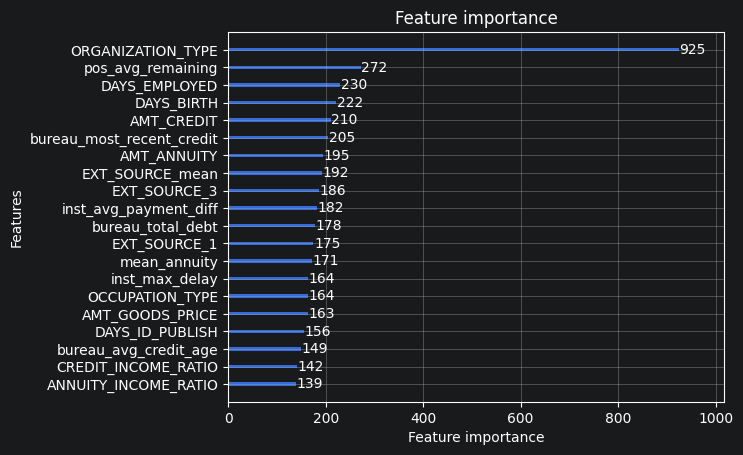

In [185]:
lgb.plot_importance(best_model, max_num_features=20)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


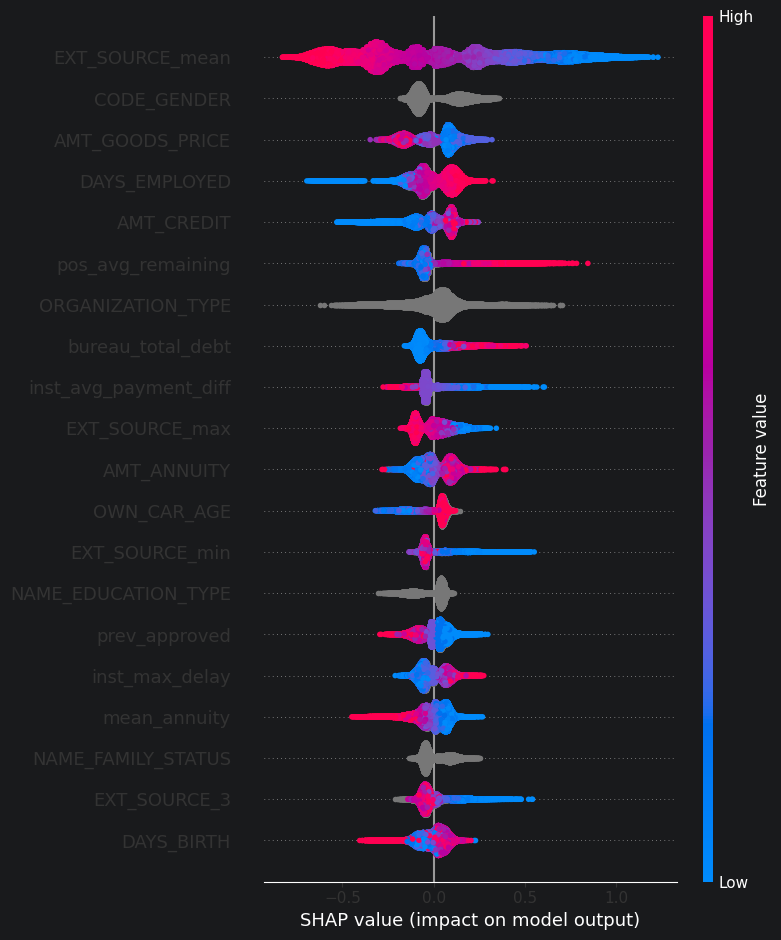

In [186]:
explainer_best = shap.TreeExplainer(best_model)
shap_val_best = explainer_best.shap_values(X)

shap.summary_plot(shap_val_best, X, max_display=20)

In [192]:
shap_importance = pd.Series(
    np.abs(shap_val_best).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

# Cutoff anschauen
print(shap_importance.head(40))
print(f"\nFeatures mit SHAP > 0.001: {(shap_importance > 0.001).sum()}")
print(f"Features mit SHAP > 0.005: {(shap_importance > 0.005).sum()}")

EXT_SOURCE_mean                     0.378066
CODE_GENDER                         0.109936
AMT_GOODS_PRICE                     0.107074
DAYS_EMPLOYED                       0.090404
AMT_CREDIT                          0.088485
pos_avg_remaining                   0.085490
ORGANIZATION_TYPE                   0.082164
bureau_total_debt                   0.078077
inst_avg_payment_diff               0.075868
EXT_SOURCE_max                      0.074220
AMT_ANNUITY                         0.071032
OWN_CAR_AGE                         0.070717
EXT_SOURCE_min                      0.068883
NAME_EDUCATION_TYPE                 0.063808
prev_approved                       0.061705
inst_max_delay                      0.061322
mean_annuity                        0.061288
NAME_FAMILY_STATUS                  0.059244
EXT_SOURCE_3                        0.057486
DAYS_BIRTH                          0.057357
mean_percentage_recieved            0.057002
OCCUPATION_TYPE                     0.051344
DAYS_ID_PU

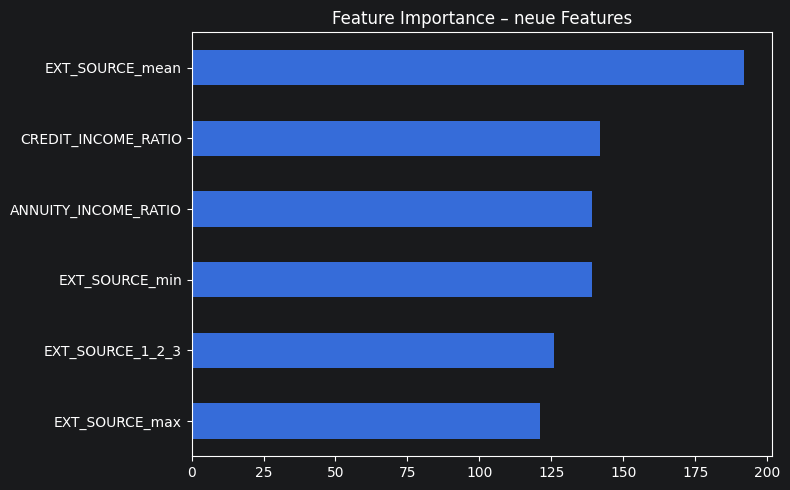

In [187]:
#neue Features
new_features = [
    'EXT_SOURCE_mean', 'EXT_SOURCE_min', 'EXT_SOURCE_max',
    'EXT_SOURCE_1_2_3', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO'
]
fi = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)[new_features].sort_values()

fi.plot(kind='barh', figsize=(8, 5), title='Feature Importance – neue Features')
plt.tight_layout()
plt.show()

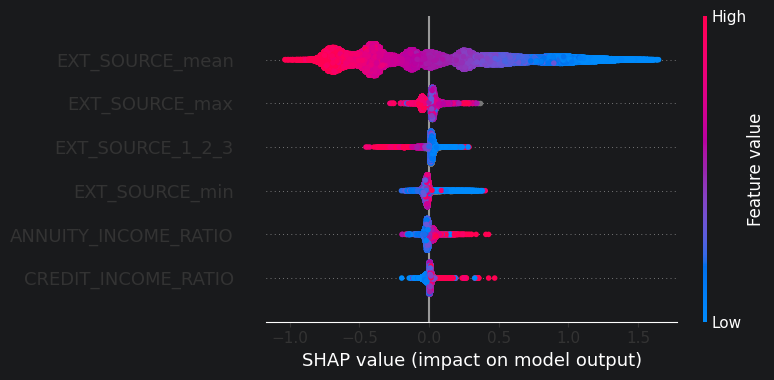

In [188]:
new_idx = [X.columns.tolist().index(f) for f in new_features]
shap.summary_plot(shap_values[:, new_idx], X[new_features])

In [203]:
print(shap_importance[(shap_importance > 0.005) & (shap_importance < 0.015)].sort_values())

FLAG_DOCUMENT_16                     0.005236
NAME_HOUSING_TYPE                    0.005252
FLAG_OWN_CAR                         0.006083
YEARS_BEGINEXPLUATATION_MEDI         0.007090
DEF_60_CNT_SOCIAL_CIRCLE             0.007147
HOUR_APPR_PROCESS_START              0.007802
bureau_oldest_credit                 0.008147
WALLSMATERIAL_MODE                   0.008878
inst_late_payments                   0.009199
cc_avg_balance                       0.009443
FLAG_PHONE                           0.009529
prev_expenses_on_other_ratio_mean    0.010025
cc_total_payment                     0.010108
max_annuity                          0.010443
pos_avg_completion                   0.010967
TOTALAREA_MODE                       0.011388
max_amt_application                  0.012854
REG_CITY_NOT_LIVE_CITY               0.012976
DAYS_REGISTRATION                    0.013456
bureau_loan_count                    0.013562
bureau_avg_credit                    0.013601
inst_avg_delay                    

In [190]:
study.best_params

{'num_leaves': 25,
 'learning_rate': 0.054078854417642847,
 'min_child_samples': 83,
 'subsample': 0.9045252850266948,
 'colsample_bytree': 0.7011960925274933,
 'reg_alpha': 1.882162376757807e-07,
 'reg_lambda': 1.1257849077723863e-07}

In [137]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=42)

#best_model = lgb.LGBMClassifier(**study.best_params, n_estimators=1000, random_state=42)
#best_model.fit(
 #   X_train_final, y_train_final,
 #   eval_set=[(X_val_final, y_val_final)],
 #   callbacks=[lgb.early_stopping(stopping_rounds=50)]
#)

In [191]:
submission3 = submission(best_model)
submission3.to_csv("submission8.csv", index=False)

In [196]:
#mal nur die wichtigsten Features
top_features = shap_importance[shap_importance > 0.005].index.tolist()
print(len(top_features))

X_train_reduced = X[top_features]
application_test_reduced = application_test[top_features]
categorical_cols_reduced = [c for c in categorical_cols if c in top_features]

76


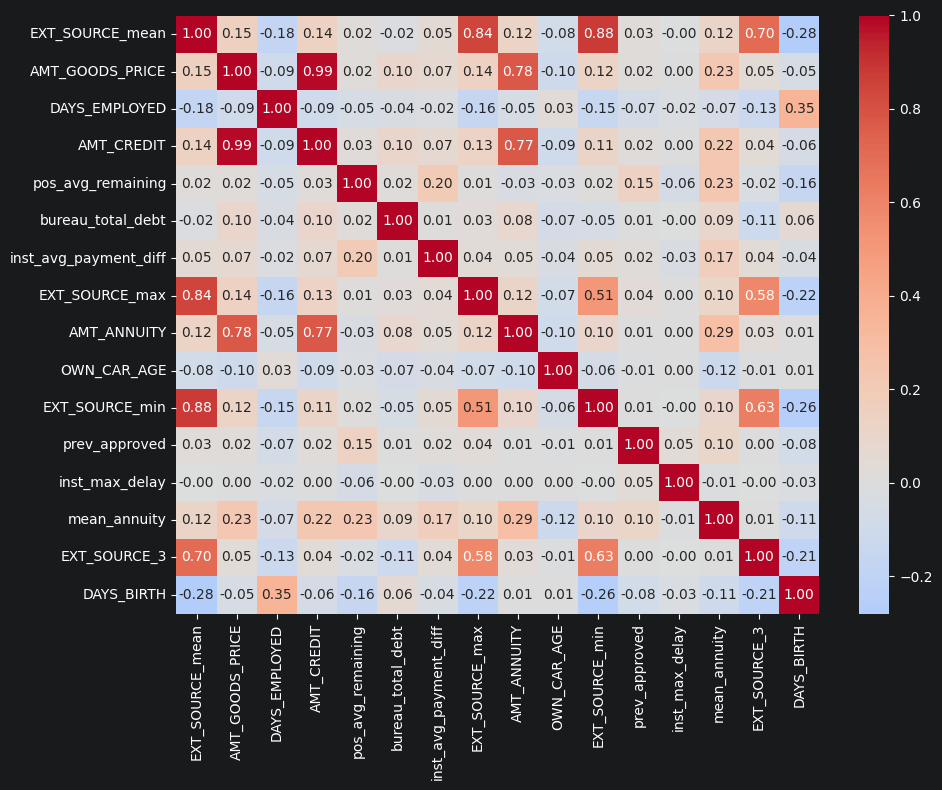

In [208]:
top_20 = shap_importance.head(20).index.tolist()
top_20_numeric = X_train_reduced[top_20].select_dtypes(include='number').columns.tolist()
corr = X_train_reduced[top_20_numeric].corr()

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

In [197]:
def objective_reduced(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators': 2000,
        'random_state': 42,
        'verbose': -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    best_iterations = []

    for train_idx, val_idx in cv.split(X_train_reduced, y):
        X_tr, X_val = X_train_reduced.iloc[train_idx], X_train_reduced.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
            categorical_feature=categorical_cols_reduced,
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))
        best_iterations.append(model.best_iteration_)

    trial.set_user_attr("best_n_estimators", int(np.mean(best_iterations)))
    return np.mean(auc_scores)

In [200]:
study = optuna.create_study(
    direction='maximize',
    storage="sqlite:///lgbm_study.db",
    study_name="lgbm_reduced_v1",
    load_if_exists=True
)

study.optimize(objective_reduced, n_trials=100)

best_n_estimators = study.best_trial.user_attrs["best_n_estimators"]
print(f"Optimale Anzahl Bäume: {best_n_estimators}")

[I 2026-05-08 14:26:00,149] Using an existing study with name 'lgbm_reduced_v1' instead of creating a new one.
[I 2026-05-08 14:26:34,944] Trial 35 finished with value: 0.7782645617468512 and parameters: {'num_leaves': 41, 'learning_rate': 0.024152336580531366, 'min_child_samples': 17, 'subsample': 0.866067110015683, 'colsample_bytree': 0.7758819060180693, 'reg_alpha': 6.740953511456708e-05, 'reg_lambda': 0.0032137076286257323}. Best is trial 32 with value: 0.7808677155816719.
[I 2026-05-08 14:27:17,329] Trial 36 finished with value: 0.7790276049610646 and parameters: {'num_leaves': 34, 'learning_rate': 0.01921095847104844, 'min_child_samples': 38, 'subsample': 0.9266908376155683, 'colsample_bytree': 0.8371151978768335, 'reg_alpha': 0.001948461802978972, 'reg_lambda': 2.603758390623475e-06}. Best is trial 32 with value: 0.7808677155816719.
[I 2026-05-08 14:27:44,112] Trial 37 finished with value: 0.777409332347696 and parameters: {'num_leaves': 62, 'learning_rate': 0.0341906590769302, 

Optimale Anzahl Bäume: 1434


In [201]:
best_model_reduced = lgb.LGBMClassifier(
    **study.best_params,
    n_estimators=best_n_estimators,
    random_state=42,
    verbose=-1,
)
best_model_reduced.fit(X, y, categorical_feature= categorical_cols_reduced)

,boosting_type,'gbdt'
,num_leaves,36
,max_depth,-1
,learning_rate,0.018318241727879808
,n_estimators,1434
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,22


In [202]:
submission_reduced = submission(best_model_reduced)
submission_reduced.to_csv("submission_reduced.csv", index=False)

In [ ]:
#Baseline XGBoost

In [ ]:
application_train.select_dtypes(exclude=["number", "category"]).columns.tolist()

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,        # Anzahl der Bäume
    learning_rate=0.05,       # Schrittweite (Eta)
    max_depth=6,              # Tiefe der Bäume
    subsample=0.8,            # Anteil der Daten pro Baum (Reihe)
    colsample_bytree=0.8,     # Anteil der Features pro Baum (Spalte)
    tree_method='hist',       # Nutzt Histogramm-Methode (viel schneller, ähnlich wie LightGBM)
    random_state=42,
    use_label_encoder=False,
    enable_categorical=True,
)

# Training mit Early Stopping
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], # Validierung auf "unbekannten" Daten
    verbose=100
)

In [ ]:
submission4 = submission(xgb_model)
submission4.to_csv("submission4.csv", index=False)

In [28]:
def objectiveXGB(trial):
    params = {
        # Diese Parameter werden von Optuna optimiert
        'n_estimators': 1000,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),

        # Wichtig für deine kategorischen Daten:
        'tree_method': 'hist',
        'enable_categorical': True,
        'random_state': 42,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)

In [30]:
studyXG = optuna.create_study(
    direction='maximize',
    storage="sqlite:///xgb_study.db",
    study_name="xgb",
    load_if_exists=True
)
studyXG.optimize(objectiveXGB, n_trials=100)
print("Beste Parameter:", studyXG.best_params)

[I 2026-05-07 16:53:22,705] A new study created in memory with name: no-name-7aecc2c4-5359-44d2-8bb2-4624a7c94d2e
[I 2026-05-07 16:55:46,972] Trial 0 finished with value: 0.7806292836902896 and parameters: {'max_depth': 5, 'learning_rate': 0.022458186981773168, 'subsample': 0.5050612734708306, 'colsample_bytree': 0.5177528618813048, 'min_child_weight': 17, 'gamma': 4.18074132566428e-08}. Best is trial 0 with value: 0.7806292836902896.
[I 2026-05-07 16:56:36,506] Trial 1 finished with value: 0.7757599667476098 and parameters: {'max_depth': 9, 'learning_rate': 0.07153029030227318, 'subsample': 0.8571102666753649, 'colsample_bytree': 0.6995958944272458, 'min_child_weight': 9, 'gamma': 2.420163184233429e-07}. Best is trial 0 with value: 0.7806292836902896.
[I 2026-05-07 16:59:46,977] Trial 2 finished with value: 0.7809046729202161 and parameters: {'max_depth': 10, 'learning_rate': 0.015842941689676714, 'subsample': 0.7913648160173448, 'colsample_bytree': 0.777568405110873, 'min_child_weigh

Beste Parameter: {'max_depth': 4, 'learning_rate': 0.04348489061471542, 'subsample': 0.9076604079332934, 'colsample_bytree': 0.9783953279336345, 'min_child_weight': 9, 'gamma': 4.181153918613525e-06}


In [33]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

best_model_XG = xgb.XGBClassifier(
    **studyXG.best_params,
    n_estimators=1000,
    random_state=42,
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=50
)
best_model_XG.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)
print(best_model_XG.best_iteration)

[0]	validation_0-logloss:0.27846
[100]	validation_0-logloss:0.24551
[200]	validation_0-logloss:0.24131
[300]	validation_0-logloss:0.23969
[400]	validation_0-logloss:0.23869
[500]	validation_0-logloss:0.23821
[600]	validation_0-logloss:0.23790
[700]	validation_0-logloss:0.23765
[800]	validation_0-logloss:0.23748
[872]	validation_0-logloss:0.23745
822


In [34]:
submission5 = submission(best_model_XG)
submission5.to_csv("submission5.csv", index=False)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

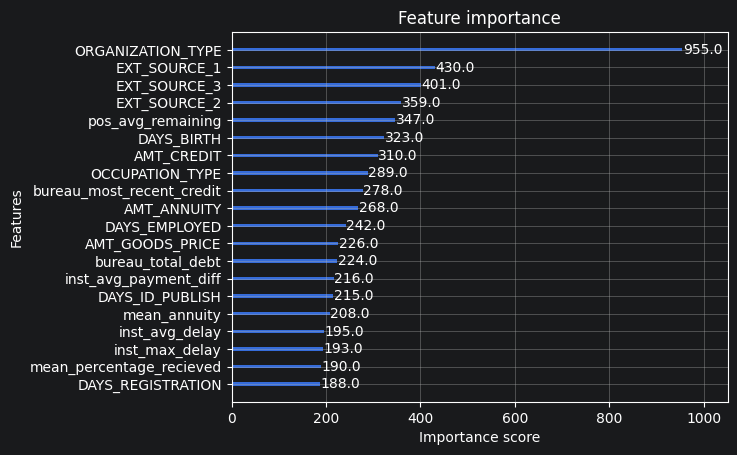

In [38]:
xgb.plot_importance(best_model_XG, max_num_features=20)